![](https://media.giphy.com/media/3o6MbrACMlFCny8zmw/giphy.gif)

Remember the rules of ~Fight~ Code Club:
1. ALWAYS DOCUMENT
2. Cite resources that you use (paste links)
3. Include the names people who you worked with
4. Be neat and organized

# Question 1

Using the dataset "us-cities-top-1k-multi-year.csv":
1. Create a line graph of total population over time for the states: NY, PA, CT, NJ (10 pts)
2. Be sure to include a title of the graph, labels on your axis, and a legend. (5 pts)
3. Specify colors to be used in your code. (5 pts)

['City', 'State', 'Population', 'lat', 'lon', 'year']
         City           State  Population        lat         lon  year
0  Marysville      Washington       63269  48.051764 -122.177082  2014
1      Perris      California       72326  33.782519 -117.228648  2014
2   Cleveland            Ohio      390113  41.499320  -81.694361  2014
3   Worcester   Massachusetts      182544  42.262593  -71.802293  2014
4    Columbia  South Carolina      133358  34.000710  -81.034814  2014


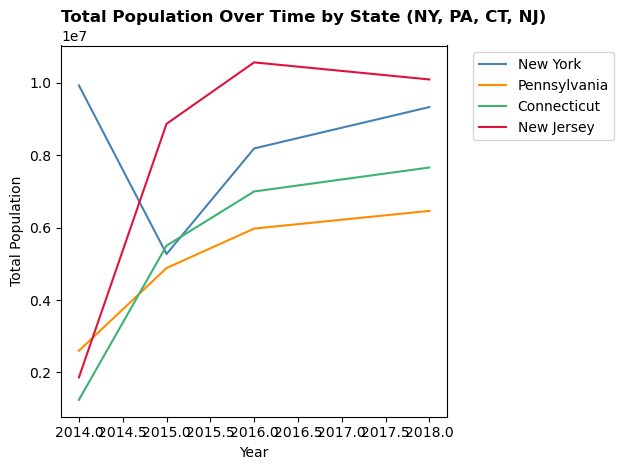

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('us-cities-top-1k-multi-year.csv')
print(df.columns.tolist())
print(df.head())

states = ['New York', 'Pennsylvania', 'Connecticut', 'New Jersey']
select_states = df[df['State'].isin(states)]

pop_time_state = select_states[['year', 'State', 'Population']].groupby(['year', 'State']).sum().reset_index()

colors = {
    'New York':      'steelblue',
    'Pennsylvania':  'darkorange',
    'Connecticut':   'mediumseagreen',
    'New Jersey':    'crimson'
}

for s in states:
    state_data = pop_time_state[pop_time_state['State'] == s]
    plt.plot(state_data['year'], state_data['Population'], label=s, color=colors[s])

plt.xlabel('Year')
plt.ylabel('Total Population')
plt.title('Total Population Over Time by State (NY, PA, CT, NJ)', loc='left', fontsize=12, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Question 2

Using the dataset "us-cities-top-1k-multi-year.csv":
1. Create a Bar Graph of the total population for 5 cities in the state of New York comparing 2014 years and 2018 years (15 pts)
2. Be sure to include a title of the graph, labels on your axis, and a legend. (5 pts)
3. Combine the graph in question 1 and question 2 in one figure.

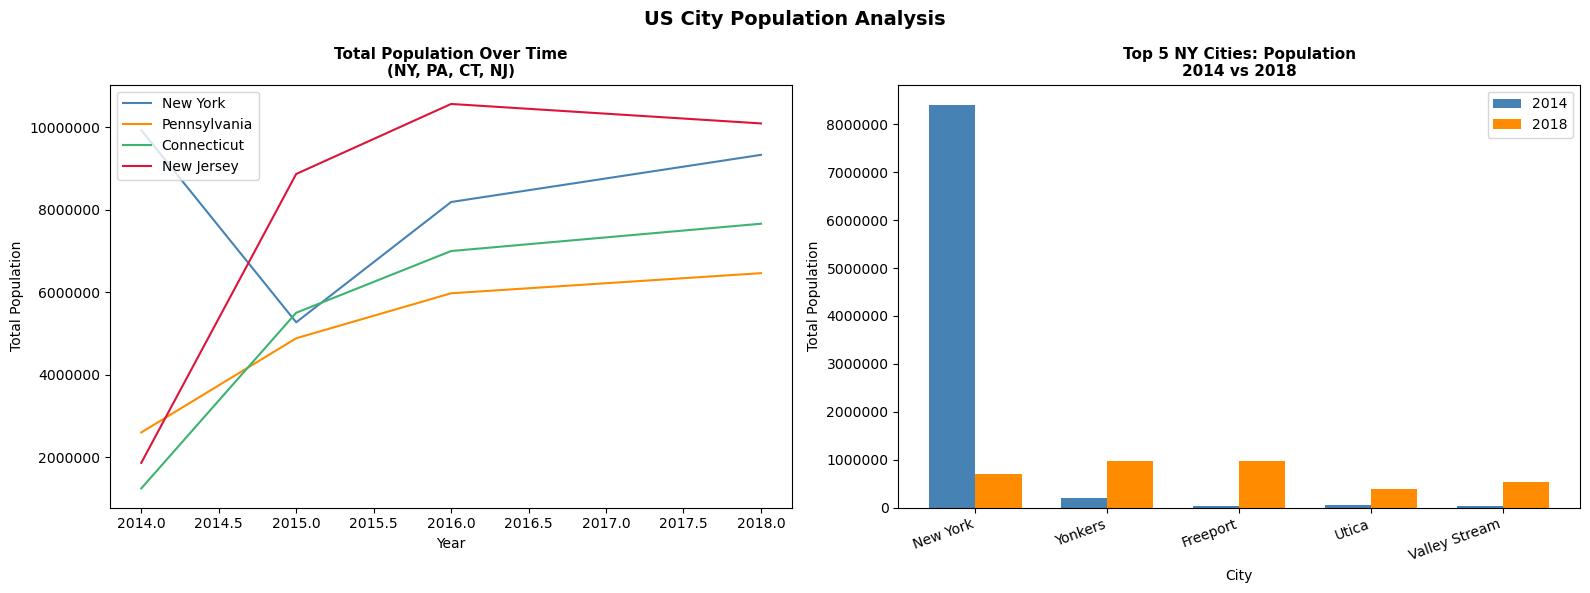

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df = pd.read_csv('us-cities-top-1k-multi-year.csv')

states = ['New York', 'Pennsylvania', 'Connecticut', 'New Jersey']
select_states = df[df['State'].isin(states)]
pop_time_state = select_states[['year', 'State', 'Population']].groupby(['year', 'State']).sum().reset_index()

colors = {
    'New York':     'steelblue',
    'Pennsylvania': 'darkorange',
    'Connecticut':  'mediumseagreen',
    'New Jersey':   'crimson'
}

ny = df[df['State'] == 'New York']
top5_cities = ny.groupby('City')['Population'].sum().nlargest(5).index.tolist()

ny_top5 = ny[ny['City'].isin(top5_cities)]
ny_2014 = ny_top5[ny_top5['year'] == 2014].set_index('City')['Population']
ny_2018 = ny_top5[ny_top5['year'] == 2018].set_index('City')['Population']

barWidth = 0.35
r1 = np.arange(len(top5_cities))
r2 = [x + barWidth for x in r1]

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

for s in states:
    state_data = pop_time_state[pop_time_state['State'] == s]
    ax1.plot(state_data['year'], state_data['Population'], label=s, color=colors[s])

ax1.set_xlabel('Year')
ax1.set_ylabel('Total Population')
ax1.set_title('Total Population Over Time\n(NY, PA, CT, NJ)', fontsize=11, fontweight='bold')
ax1.legend(loc='upper left')
ax1.ticklabel_format(axis='y', style='plain')

ax2.bar(r1, ny_2014[top5_cities], width=barWidth, color='steelblue',   label='2014')
ax2.bar(r2, ny_2018[top5_cities], width=barWidth, color='darkorange',  label='2018')

ax2.set_xlabel('City')
ax2.set_ylabel('Total Population')
ax2.set_title('Top 5 NY Cities: Population\n2014 vs 2018', fontsize=11, fontweight='bold')
ax2.set_xticks([r + barWidth / 2 for r in range(len(top5_cities))])
ax2.set_xticklabels(top5_cities, rotation=20, ha='right')
ax2.ticklabel_format(axis='y', style='plain')
ax2.legend()

fig.suptitle('US City Population Analysis', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

## Question 3

import the data "job-automation-probability.csv"
1. A Histogram of the variable 'probability'
2. A scatter plot of 'Average annual wage' and 'numbEmployed'
3. Put both of these graphs in one figure
4. Using item 3, change the ticks of Number Employed axes so that it is in logarithmic axis (hint: it's an option) 
5. Adding onto item 4, add a title and axis labels
6. Save your figure as a png

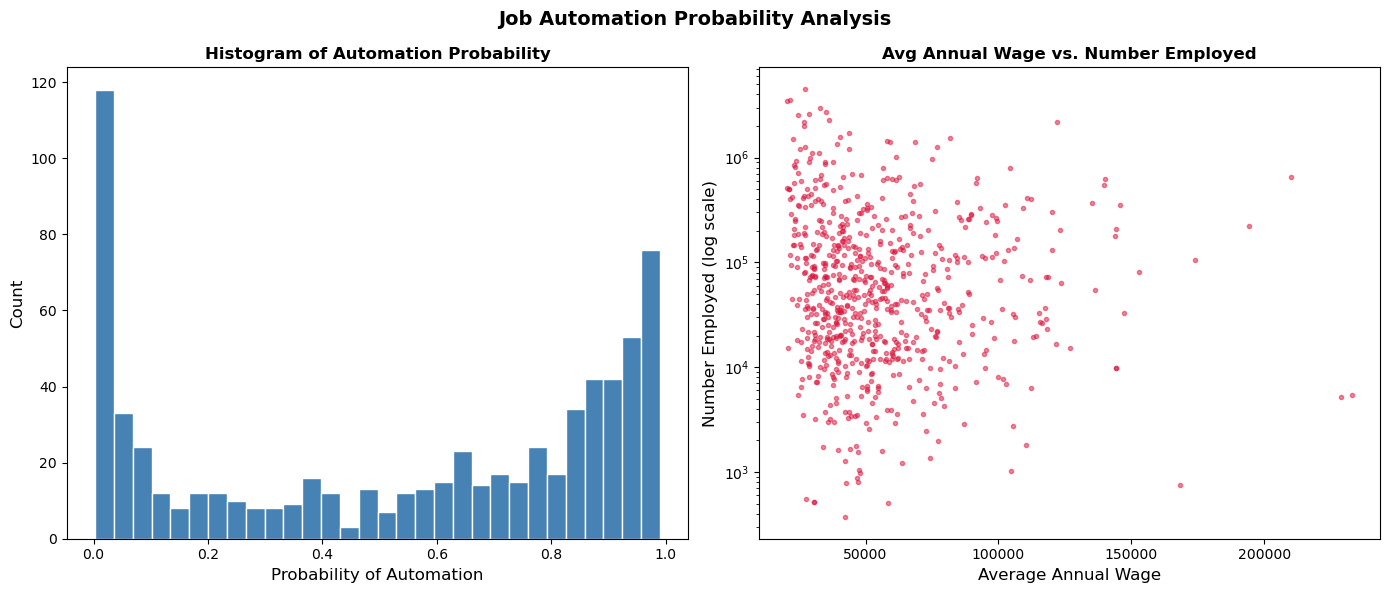

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

jobs = pd.read_csv('job-automation-probability.csv')


fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

ax1.hist(jobs['probability'], bins=30, color='steelblue', edgecolor='white')
ax1.set_xlabel('Probability of Automation', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('Histogram of Automation Probability', fontsize=12, fontweight='bold')

ax2.scatter(jobs['Average annual wage'], jobs['numbEmployed'],
            color='crimson', marker='.', alpha=0.5)
ax2.set_xlabel('Average Annual Wage', fontsize=12)
ax2.set_ylabel('Number Employed (log scale)', fontsize=12)
ax2.set_title('Avg Annual Wage vs. Number Employed', fontsize=12, fontweight='bold')

ax2.set_yscale('log')

ax2.ticklabel_format(axis='x', style='plain')

fig.suptitle('Job Automation Probability Analysis', fontsize=14, fontweight='bold')

fig.tight_layout()

plt.savefig('job_automation_analysis.png', dpi=300, bbox_inches='tight')

plt.show()